# Boosting (EDA-9)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib

## Import data

In [5]:
# Reading data
X_train = pd.read_csv('../../data/processed/X_train_eda9.csv')
X_test = pd.read_csv('../../data/processed/X_test_eda9.csv')
y_train = pd.read_csv('../../data/processed/y_train_eda9.csv')
y_test = pd.read_csv('../../data/processed/y_test_eda9.csv')

## Escalado

In [6]:
from sklearn.preprocessing import StandardScaler

scaler_xgb = StandardScaler()

X_train_scaled = scaler_xgb.fit_transform(X_train)
X_test_scaled = scaler_xgb.transform(X_test)


## Creating model and training data - XGBoost

In [7]:
# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, 
                          subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train_scaled, y_train.values.ravel())

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [10]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [11]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [12]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.510001928505058,
 0.5136635160680529,
 0.5886145048089421,
 0.5485908099814262,
 0.5204173785874866)

In [14]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
0.0,0.504953,0.429532,0.464199,56373.000000
1.0,0.513664,0.588615,0.548591,57705.000000
accuracy,0.510002,0.510002,0.510002,0.510002
macro avg,0.509308,0.509073,0.506395,114078.000000
weighted avg,0.509359,0.510002,0.506887,114078.000000


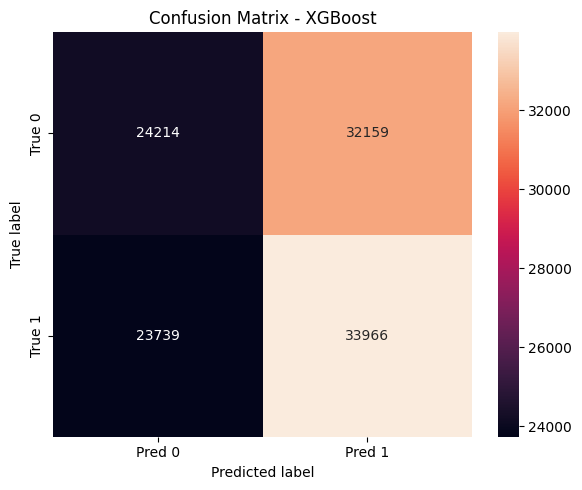

In [15]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - XGBoost')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [16]:
# Classification report
classification_report(y_test, y_pred, digits=3)

'              precision    recall  f1-score   support\n\n         0.0      0.505     0.430     0.464     56373\n         1.0      0.514     0.589     0.549     57705\n\n    accuracy                          0.510    114078\n   macro avg      0.509     0.509     0.506    114078\nweighted avg      0.509     0.510     0.507    114078\n'

## Optimization

In [17]:
# Hyperparameters to test
hyperparams = {'n_estimators' : [100, 200],
               'learning_rate' : [0.05, 0.1],
               'max_depth' : [2, 3, 4],
               'min_split_loss' : [0, 0.1],
               'subsample' : [0.7, 0.8],
               'colsample_bytree' : [0.7, 0.8]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search = GridSearchCV(xgb_model, hyperparams, scoring='roc_auc', cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train.values.ravel())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_split_loss': [0, 0.1], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [18]:
# Best parameters and evaluation
grid_model_xgb = grid_search.best_estimator_

y_pred_opt = grid_model_xgb.predict(X_test)
y_proba_opt = grid_model_xgb.predict_proba(X_test)[:,1]

In [19]:
# Metrics for optimized model
test_accuracy = accuracy_score(y_test, y_pred_opt)
test_precision = precision_score(y_test, y_pred_opt)
test_recall = recall_score(y_test, y_pred_opt)
test_f1 = f1_score(y_test, y_pred_opt)
test_roc_auc = roc_auc_score(y_test, y_proba_opt)

In [20]:
# Showing results
test_accuracy, test_precision, test_recall, test_f1, test_roc_auc

(0.5104314591770543,
 0.5140973445950051,
 0.5864656442249372,
 0.5479021799842957,
 0.5186086605338645)

In [21]:
report_dict2 = classification_report(y_test, y_pred_opt, output_dict=True)
df_report2 = pd.DataFrame(report_dict2).transpose()
df_report2

,precision,recall,f1-score,support
0.0,0.505430,0.432601,0.466188,56373.000000
1.0,0.514097,0.586466,0.547902,57705.000000
accuracy,0.510431,0.510431,0.510431,0.510431
macro avg,0.509764,0.509533,0.507045,114078.000000
weighted avg,0.509814,0.510431,0.507522,114078.000000


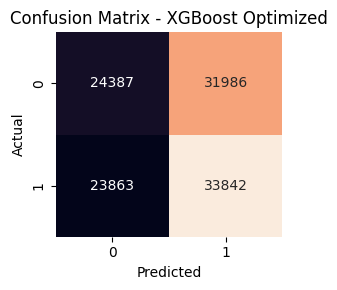

In [22]:
cm = confusion_matrix(y_test, y_pred_opt)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost Optimized')

plt.tight_layout()
plt.show()

## Creating model and training data - Gradient Boosting

In [23]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)

# Train the model
gb_model.fit(X_train, y_train.values.ravel())

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Predictions

In [24]:
# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

In [25]:
# Evaluate accuracy and other metrics
model_accuracy_gb = accuracy_score(y_test, y_pred_gb)
model_precision_gb = precision_score(y_test, y_pred_gb)
model_recall_gb = recall_score(y_test, y_pred_gb)
model_f1_gb = f1_score(y_test, y_pred_gb)
model_roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

In [26]:
# Showing results
model_accuracy_gb, model_precision_gb, model_recall_gb, model_f1_gb, model_roc_auc_gb

(0.5083188695453987,
 0.512767000268779,
 0.5620310198423014,
 0.5362699869371828,
 0.5193544093943334)

In [27]:
report_dict3 = classification_report(y_test, y_pred_gb, output_dict=True)
df_report3 = pd.DataFrame(report_dict3).transpose()
df_report3

,precision,recall,f1-score,support
0.0,0.502784,0.453338,0.476782,56373.000000
1.0,0.512767,0.562031,0.536270,57705.000000
accuracy,0.508319,0.508319,0.508319,0.508319
macro avg,0.507775,0.507684,0.506526,114078.000000
weighted avg,0.507834,0.508319,0.506873,114078.000000


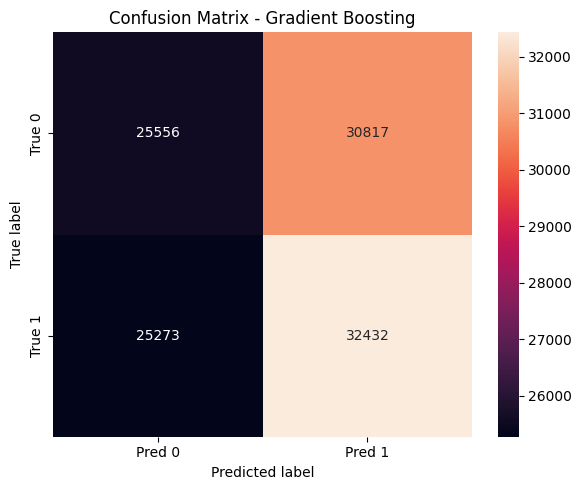

In [28]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [29]:
# Classification report
classification_report(y_test, y_pred_gb, digits=3)

'              precision    recall  f1-score   support\n\n         0.0      0.503     0.453     0.477     56373\n         1.0      0.513     0.562     0.536     57705\n\n    accuracy                          0.508    114078\n   macro avg      0.508     0.508     0.507    114078\nweighted avg      0.508     0.508     0.507    114078\n'

## Optimization

In [30]:
# Hyperparameters to test
hyperparams_gb = {'n_estimators' : [100, 200],
                  'learning_rate' : [0.05, 0.1],
                  'max_depth' : [2, 3, 4],
                  'subsample' : [0.7, 0.8],
                  'max_features' : ['sqrt', 'log2']}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search_gb = GridSearchCV(gb_model, hyperparams_gb, scoring='roc_auc', cv=tscv, n_jobs=-1)
grid_search_gb.fit(X_train, y_train.values.ravel())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...subsample=0.8)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [31]:
# Best parameters and evaluation
grid_model_gb = grid_search_gb.best_estimator_

y_pred_gb_opt = grid_model_gb.predict(X_test)
y_proba_gb_opt = grid_model_gb.predict_proba(X_test)[:,1]

In [32]:
# Metrics for optimized model
test_accuracy_gb = accuracy_score(y_test, y_pred_gb_opt)
test_precision_gb = precision_score(y_test, y_pred_gb_opt)
test_recall_gb = recall_score(y_test, y_pred_gb_opt)
test_f1_gb = f1_score(y_test, y_pred_gb_opt)
test_roc_auc_gb = roc_auc_score(y_test, y_proba_gb_opt)

In [33]:
# Showing results
test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb, test_roc_auc_gb

(0.5101421834183629,
 0.5139734175468719,
 0.5810068451607313,
 0.5454382768269669,
 0.5180943712744598)

In [34]:
report_dict4 = classification_report(y_test, y_pred_gb_opt, output_dict=True)
df_report4 = pd.DataFrame(report_dict4).transpose()

df_report4

,precision,recall,f1-score,support
0.0,0.505026,0.437603,0.468903,56373.000000
1.0,0.513973,0.581007,0.545438,57705.000000
accuracy,0.510142,0.510142,0.510142,0.510142
macro avg,0.509500,0.509305,0.507171,114078.000000
weighted avg,0.509552,0.510142,0.507618,114078.000000


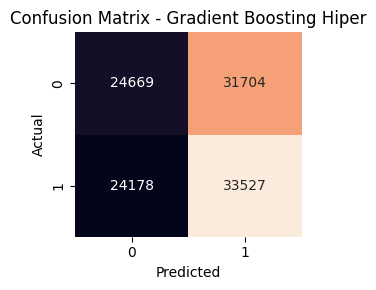

In [35]:
bank_cm4 = confusion_matrix(y_test, y_pred_gb_opt)

# Dibujaremos esta matriz para hacerla más visual
df_cm4 = pd.DataFrame(bank_cm4)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm4, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting Hiper')

plt.tight_layout()
plt.show()

## Save model

In [36]:
# Saving best model
joblib.dump(grid_model_xgb, '../../models/xgboost-model-final.pkl')

['../../models/xgboost-model-final.pkl']

In [38]:
# Saving Scaler
joblib.dump(scaler_xgb, '../../models/scaler.pkl')

['../../models/scaler.pkl']